In [2]:
import pynbody as pn
import matplotlib
matplotlib.rcParams['animation.ffmpeg_path'] = '/opt/homebrew/bin/ffmpeg'
import matplotlib.pyplot as plt
import numpy as np
import pynbody.filt as filt
from pynbody.analysis import profile
import os
from matplotlib.animation import FuncAnimation
from scipy.stats import gaussian_kde
from scipy import optimize
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import maximum_filter
from scipy.special import gamma, factorial
from scipy.integrate import nquad
from scipy.integrate import cumulative_trapezoid
import seaborn as sns
import scipy.special as sc
from scipy.spatial import cKDTree
import scipy.integrate as integrate
import seaborn as sns
sns.set_style("white") # setting style
sns.set_context('notebook') # setting context
palette = [
    "pink", "hotpink","palevioletred", "orchid","thistle","mediumpurple","mediumslateblue","slateblue"
]
sns.set_palette("tab10")
G = 4.302e-3 #pc/M_sol/km/s**2
a0 = 1.2e-10 # m/s**2
a0_kms_pc = 1.2e-10 * (1e-3)**2 * 3.086e16

In [3]:

def write_ramses_txt(filename, pos, vel, mass):
    """
    pos  : [kpc]
    vel  : [km/s] 
    mass : [Msun]
    """
    N = len(mass)
    pos  = np.array(pos)   # strip pynbody units
    vel  = np.array(vel)
    mass = np.array(mass)
    with open(filename, 'w') as f:
        for i in range(N):
            f.write(
                f"{pos[i,0]:.6f},{pos[i,1]:.6f},{pos[i,2]:.6f},"
                f"{vel[i,0]:.6f},{vel[i,1]:.6f},{vel[i,2]:.6f},"
                f"{mass[i]:.6e}\n"  # no trailing space
            )
    print(f"Written {N} particles to {filename}")
    
def sigma(v):
    return np.std(v)

def get_single_snapshot(filename, i):
    f = f"{filename}output_{i:05d}"
    s = pn.load(f)
    pn.analysis.halo.center(s.dm, vel=False)
    #be clear about units
    p = np.array(s.dm['pos'].in_units('kpc'))
    v = np.array(s.dm['vel'].in_units('km s^-1'))
    m = np.array(s.dm['mass'].in_units('Msol'))
    return p, v, m

def plot_setup(filename, N_per_bin=50):
    data = np.loadtxt(filename, delimiter=',')
    pos  = data[:, 0:3]
    vel  = data[:, 3:6]
    mass = data[:, 6]

    x, y, z = pos[:, 0], pos[:, 1], pos[:, 2]
    vx, vy, vz = vel[:, 0], vel[:, 1], vel[:, 2]
    sigmas = np.sqrt(sigma(vx)**2 + sigma(vy)**2 + sigma(vz)**2)

    eps = 1e-12

    r = np.sqrt(x**2 + y**2 + z**2)
    sort_idx = np.argsort(r)
    r_sorted = r[sort_idx]
    m_cumul  = np.cumsum(mass[sort_idx])
    
    r_safe = np.maximum(r, eps)

    vr = (x*vx + y*vy + z*vz) / r_safe
    v3d = np.sqrt(vx**2 + vy**2 + vz**2)
    vt = np.sqrt(np.maximum(v3d**2 - vr**2, 0.0))

    R_cyl = np.sqrt(x**2 + y**2)
    R_safe = np.maximum(R_cyl, eps)

    edge_idx = np.arange(0, len(r), N_per_bin)
    r_edges  = r_sorted[edge_idx]
    
    M_enc = np.interp(r_edges, r_sorted, m_cumul)
    
    rho = []
    r_centers = []
    vc = []
    v_t = []
    v_z = []

    for i in range(len(r_edges)-1):
        r_in = r_edges[i]
        r_out = r_edges[i + 1]
        
        shell = (r >= r_in) & (r < r_out)
        m_shell = mass[shell].sum()
        vol_shell = (4.0 / 3.0) * np.pi * (r_out**3 - r_in**3)
        rho.append(m_shell / vol_shell)
        
        r_centers.append(np.sqrt(r_in * r_out))
        vc.append(np.mean(np.abs(vr[shell])))
        v_t.append(np.mean(np.abs(vt[shell])))
        v_z.append(np.mean(np.abs(vz[shell])))
        

    com = np.average(pos, weights=mass, axis=0)
    comv = np.average(vel, weights=mass, axis=0)

    fig = plt.figure(figsize=(14, 10))

    ax1 = fig.add_subplot(221, projection="3d")
    ax1.scatter(x, y,z, c="grey", s=1, label="Particles")
    ax1.set_xlabel('x [kpc]')
    ax1.set_ylabel('y [kpc]')
    ax1.set_zlabel('z [kpc]')
    ax1.grid(True, alpha = 0.4)
    ax1.set_title('3D positions')

    ax2 = fig.add_subplot(224)
    ax2.scatter(r, vr,  c="k",  s=3, label=r'$v_r$ (radial)')
    ax2.scatter(r, vt,  c="b", s=3,  label=r'$v_t$ (tangential)')
    ax2.scatter(r, vz,  c="r",  s=3,   label=r'$v_z$ ')
    ax2.set_xlabel('r [kpc]')
    ax2.set_ylabel('Velocity [km/s]')
    ax2.set_title('Radial, tangential, and vertical components')
    ax2.grid(True, alpha = 0.4)
    ax2.legend(markerscale=4)

    ax3 = fig.add_subplot(223)
    ax3.scatter(vx, vy, s=2, c="grey" , label="Velocities")
    ax3.set_xlabel('$v_x$ [km/s]')
    ax3.set_ylabel('$v_y$ [km/s]')
    ax3.set_title('Velocity plane: $v_x$-$v_y$')
    ax3.grid(True, alpha = 0.4)
    ax3.legend(markerscale=4)

    ax4 = fig.add_subplot(222)
    ax4.loglog(r_centers, rho, c="k",marker='o', ms=3, lw=1)
    ax4.set_xlabel('r [kpc]')
    ax4.set_ylabel(r'$\rho$ $[M_{\odot} / kpc]$ ')
    ax4.grid(True, alpha = 0.4)
    ax4.set_title('Density profile')

    plt.tight_layout()
    plt.show()

    print(f"N particles     : {len(mass)}")
    print(f"Total mass      : {mass.sum():.3e} Msun")
    print(f"Max radius      : {np.sqrt((pos**2).sum(axis=1)).max():.2f} kpc")
    print(f"Mean speed      : {np.sqrt((vel**2).sum(axis=1)).mean():.2f} km/s")
    print(f"Total sigma     : {sigmas:.2f} km/s")
    print(f"CoM position    : {com}")
    print(f"CoM velocity    : {comv}")
    
    return r_centers, rho, M_enc

def merge_gal_shift(hostname, satellitename, ph, vh, ps,vs):
    """
    x,y,z        : dwarf location [kpc] from DICE ouptut
    vy, vy, vz   : dwarf velocity [km/s] from DICE ouptut
    """
    
    data_host = np.loadtxt(hostname, delimiter=',')
    posh  = data_host[:, 0:3]
    velh  = data_host[:, 3:6]
    massh = data_host[:, 6]
    
    data_sat = np.loadtxt(satellitename, delimiter=',')
    poss  = data_sat[:, 0:3]
    vels = data_sat[:, 3:6]
    masss = data_sat[:, 6]
    
    
    #shift host
    posh[:,0] += ph[0] #kpc
    posh[:,1] += ph[1]
    posh[:,2] += ph[2]
    
    velh[:,0] += vh[0] #km/s
    velh[:,1] += vh[1]
    velh[:,2] += vh[2]
    
    #shift satellite
    poss[:,0] += ps[0] #kpc
    poss[:,1] += ps[1]
    poss[:,2] += ps[2]
    
    vels[:,0] += vs[0] #km/s
    vels[:,1] += vs[1]
    vels[:,2] += vs[2]
    
    pos_all  = np.vstack([posh,  poss])
    vel_all  = np.vstack([velh,  vels])
    mass_all = np.concatenate([massh, masss])   
    
    write_ramses_txt('/Users/olgahinke/Desktop/Uni/THESIS/codes/host_with_dwarf.txt',pos_all, vel_all, mass_all)

def dwarf_setup_last(output, i, filename, single = True, N_host = 6000):
    if single == True:
        p, v, m = get_single_snapshot(output, i)
    else:
        p, v, m = get_single_snapshot(output, i, N_host)
        
    write_ramses_txt(f"/Users/olgahinke/Desktop/Uni/THESIS/codes/{filename}", p, v, m)
    
def v_inf(M):
    # returns km/s
    return (G * M * a0_kms_pc) ** (1/4)

def g_ext(R, M):
    R = R * 1e3 #convert to pc
    M = float(M)
    return (v_inf(M)**2/R)/a0_kms_pc #  in a0 units

def get_beta(v, R, r, M):
    # Brada 2000
    # EFE importance: beta << 1 means EFE dominated
    # beta = v^2 / (r_pc * g_ext)
    # [km^2/s^2] / [pc * km^2/s^2/pc] = dimensionless ✓
    v   = float(v)
    r   = float(r)*1e3
    R   = float(R)*1e3
    M   = float(M)
    return (v**2 * R) / (v_inf(M)**2 * r)

def get_alpha(v, r, R, M):
    # Brada 2000
    # Tidal importance: alpha << 1 means tidal dominated
    # alpha = (v * R / (r * v_inf))^(2/3) — all in same units, dimensionless ✓
    v   = float(v)
    r   = float(r)   # kpc — R/r ratio, units cancel
    R   = float(R)   # kpc
    M   = float(M)

def sigma_1d(v):
    return np.std(v)

def lagrangian_radius(snapshot, center, fraction=0.99):
    pos  = snapshot["pos"]
    mass = snapshot["mass"]
    center = np.asarray(center, dtype=float).flatten()
    r = np.linalg.norm(pos - center, axis=1)
    sort_idx = np.argsort(r)
    m_cumul  = np.cumsum(mass[sort_idx])
    return np.interp(fraction * m_cumul[-1], m_cumul, r[sort_idx])

def rms_radius(snapshot, center):
    pos  = snapshot["pos"]         
    mass = snapshot["mass"]
    center = np.asarray(center, dtype=float).flatten()
    r  = np.linalg.norm(pos - center, axis=1)  # center must be in same units as pos
    return np.sqrt(np.average(r**2, weights=mass))

def sersic_a(r_e, n):
    return r_e * np.exp(0.1789 - 0.6950*n - n * np.log(n))

def sersic_p(n):
    return 1 - 0.6097/n + 0.05563/n**2

def sersic_rho_0(M, n, r_e): 
    gam = gamma(3 * n - n * sersic_p(n))
    return M/(4 * np.pi * n * sersic_a(r_e, n)**3 * gam)

def sersic_density(r, M, n, r_e):
    ra = r/sersic_a(r_e, n)
    return sersic_rho_0(M, n, r_e) * (ra)**(-sersic_p(n)) * np.exp(-(ra)**(1/n))

def nu_mond(y):
    return 1/2 + np.sqrt(1/4 + 1/y)

def g_newton(r, M_enc):
    return G * M_enc / r**2

def g_mond(r_pc_array, M_enc_array, R_kpc, M_host):
    gN      = g_newton(r_pc_array, M_enc_array)
    R_pc    = R_kpc * 1e3
    gNe     = G * M_host / R_pc**2
    g_N_tot = gN + gNe
    nu      = nu_mond(g_N_tot / a0_kms_pc)
    return nu * gN

def mond_potential(r_array, mass_enc_array, R_kpc, M_host, n_ext=200):
    r_array        = np.maximum(np.asarray(r_array, dtype=float), 1.0)  # 1pc floor only
    mass_enc_array = np.asarray(mass_enc_array, dtype=float)
    M_tot  = float(mass_enc_array[-1])
    r_max  = float(r_array[-1])
    R_pc   = R_kpc * 1e3
    gNe    = G * M_host / R_pc**2
    r_efe_pc = v_inf(M_tot)**2 / gNe

    r_cutoff = max(r_efe_pc * 10, r_max * 3)
    r_tail   = np.linspace(r_max, r_cutoff, n_ext)

    g_tail   = g_mond(r_tail,   M_tot,          R_kpc, M_host)
    g_main   = g_mond(r_array,  mass_enc_array,  R_kpc, M_host)

    phi_tail = cumulative_trapezoid(g_tail[::-1], r_tail[::-1], initial=0)[::-1]
    phi_main = cumulative_trapezoid(g_main[::-1], r_array[::-1], initial=0)[::-1]
    phi_main += phi_tail[0]

    return phi_main

def velocity_dispersion_profile(pos, vel, com_pos, com_vel, rbins, min_particles=20):
    """
    pos, vel   : (N,3) arrays in kpc and km/s
    com_pos/vel: satellite COM
    rbins      : bin edges in kpc
    """
    rel_pos = pos - com_pos
    rel_vel = vel - com_vel
    r = np.linalg.norm(rel_pos, axis=1)
    
    sigma_profile = []
    r_centers     = []
    n_particles   = []
    
    for j in range(len(rbins) - 1):
        r_in  = rbins[j]
        r_out = rbins[j+1]
        shell = (r >= r_in) & (r < r_out)
        
        if shell.sum() < min_particles:  # raise threshold from 5 to 20
            sigma_profile.append(np.nan)
            r_centers.append(np.sqrt(r_in * r_out))  # geometric mean, better for log bins
            n_particles.append(shell.sum())
            continue
        
        r_shell   = r[shell]
        # Bug fix: avoid division by zero for particles exactly at center
        r_safe    = np.maximum(r_shell, 1e-10)
        r_hat     = rel_pos[shell] / r_safe[:, np.newaxis]
        
        v_rad     = np.sum(rel_vel[shell] * r_hat, axis=1)
        v_tan     = rel_vel[shell] - v_rad[:, np.newaxis] * r_hat
        
        sigma_r   = np.std(v_rad)
        # Bug fix: tangential has 2 DOF, std of |v_tan| != sigma per component
        # correct: sigma_t per component = std of each tangential component separately
        sigma_t1  = np.std(v_tan[:, 0])
        sigma_t2  = np.std(v_tan[:, 1])
        sigma_t3  = np.std(v_tan[:, 2])
        sigma_3d  = np.sqrt(sigma_r**2 + sigma_t1**2 + sigma_t2**2 + sigma_t3**2) / np.sqrt(3)

        # Line of sight (most comparable to observations)
        sigma_los = np.std(rel_vel[shell, 2])
        
        sigma_profile.append(sigma_los)
        r_centers.append(np.sqrt(r_in * r_out))
        n_particles.append(shell.sum())
    
    return np.array(r_centers), np.array(sigma_profile), np.array(n_particles)

In [4]:
def plotting_single(filename, dt, t_end, N_host, movie = True, cutoff = 10):
    coms_h1 = []
    lags = []
    hmrs = []
    
    all_pos = []
    all_mass = []
    all_vel = []
    times = []
    t = 0
    bins1 = []
    rhos1 = []
    rs = []
    sigmas = []
    sigmas_bin = []

    for i in range(1,t_end + 1):
        f = f"{filename}output_{i:05d}"
        s = pn.load(f)
        
        if i == 1:
            ids_dwarf = np.array(s.dm['iord'][N_host:])  # or [:N_host] depending on ordering

            # Every snapshot, mask to dwarf only
            mask_dwarf = np.isin(s.dm['iord'], ids_dwarf)

            pos  = np.array(s.dm['pos'][mask_dwarf])
            mass = np.array(s.dm['mass'][mask_dwarf])
            vel  = np.array(s.dm['vel'][mask_dwarf].in_units('km s^-1'))

            print(f"Dwarf mass: {np.sum(mass):.2e} M_sun")  # should now be dwarf
            print(f"Total particles: {len(s.dm)}")
            print(f"N_host:          {N_host}")
            print(f"First particle mass:  {s.dm['mass'][0]:.2e}")
            print(f"Last particle mass:   {s.dm['mass'][-1]:.2e}")
            print(f"Mass of first N_host: {np.sum(s.dm['mass'][:N_host]):.2e}")
            print(f"Mass of rest:         {np.sum(s.dm['mass'][N_host:]):.2e}") 
            
        pn.analysis.halo.center(s.dm[mask_dwarf]) 
        pos = s.dm["pos"]
        all_pos.append(pos)
        mass = s.dm["mass"]
        all_mass.append(mass)
        vel = np.array(s.dm['vel'].in_units('km s^-1')) #UNIT CONVERSION
        all_vel.append(vel)
        
        com1 = np.average(pos[mask_dwarf], weights=mass[mask_dwarf], axis=0)
        com_vel = np.average(vel[mask_dwarf], weights=mass[mask_dwarf], axis=0)
        coms_h1.append(com1)
        lag = lagrangian_radius(s.dm[mask_dwarf], com1, fraction = 0.99)
        hmr = lagrangian_radius(s.dm[mask_dwarf], com1, fraction= 0.5)
        lags.append(lag)
        hmrs.append(hmr)

        p1 = pn.analysis.profile.Profile(s.dm,min=0.0001,max=cutoff, ndim=3, type="equaln", nbins=300) 
        rhos1.append(p1['density']) 
        bins1.append(p1['rbins'])
    
        vx, vy, vz = vel[:, 0], vel[:, 1], vel[:, 2]
        sigma_x = sigma_1d(vx)
        sigma_y = sigma_1d(vy)
        sigma_z = sigma_1d(vz)
        sigmas.append(np.sqrt((sigma_x**2 + sigma_y**2 + sigma_z**2)))

        rbins_prof = np.logspace(np.log10(0.05), np.log10(cutoff), 50)
        r_centers, sigma_prof, n_prof = velocity_dispersion_profile(pos[mask_dwarf], vel[mask_dwarf], com1, com_vel, rbins_prof)
        sigmas_bin.append(sigma_prof)
        
        t += dt
        times.append(t)
        
    if movie == True:
        fig, ax = plt.subplots(figsize=(10, 10))
        scat_particles = ax.scatter([], [], s=1, alpha=0.6,c='gray', label='All particles')
        scat_com1 = ax.scatter([], [], s=50, marker = "x", c='red', label='Halo 1 COM', zorder=10)
        ax.set_xlim(-15, 15)
        ax.set_ylim(-15, 15)
        ax.set_xlabel('X [kpc]')
        ax.set_ylabel('Y [kpc]')

        def update(frame):
            pos_xy = all_pos[frame][:, :2]
            com1_xy = np.array(coms_h1[frame])[:2].reshape(1, -1)  # fixed
            
            scat_particles.set_offsets(pos_xy)
            scat_com1.set_offsets(com1_xy)
    
            time_text.set_text(f't = {times[frame]} Myr')
            title_text = ax.text(0.5, 1.02, '', transform=ax.transAxes, ha='center', fontsize=12)
            title_text.set_text(f"Dwarf mass: {np.sum(all_mass[frame]):.2e} $M_{{\odot}}$")
            return scat_particles, scat_com1, time_text, title_text
        
        time_text = ax.text(0.05, 0.95,          # x, y in axes coordinates (top-left)
    '',                   # starts empty, filled by update()
    transform=ax.transAxes,
    fontsize=12,
    color='black',        # adjust to suit your background
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.4)  # optional box
    )
        
        ax.legend(loc='upper right')
        anim = FuncAnimation(fig, update, frames=len(times),interval=500, blit=True)

        anim.save(f"{filename}com_check.mp4", fps=2, dpi=150, extra_args=['-vcodec', 'libx264'])
        print(f"Movie saved as {filename}com_check.mp4")
        plt.close(fig)        

    return np.array(times), all_pos, all_vel, all_mass, np.array(rs), np.array(sigmas), np.array(rhos1), np.array(bins1), lags, hmrs, r_centers, sigmas_bin


In [5]:
d = "/Volumes/Festplatte/single_dwarfs/mw/"
t, _, _, _, r, sigma, rho, bins, lag, hmr, cent, sig_bin = plotting_single(d, 100, 3, N_host = 0, movie = True, cutoff = 10)

/opt/miniconda3/envs/pynbody_env/lib/python3.10/site-packages/pynbody/snapshot/ramses.py:826: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn("Using field %s to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher."%pb_name)
/opt/miniconda3/envs/pynbody_env/lib/python3.10/site-packages/pynbody/snapshot/ramses.py:1036: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +
Process SpawnPoolWorker-8:
Process SpawnPoolWorker-7:
Traceback (most recent call last):
  File "/opt/miniconda3/envs/pynbody_env/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/miniconda3/envs/pynbody_env/lib/python3.10/multiproc

KeyboardInterrupt: 

In [ ]:
dwarf_setup_last(d, 81, "sers_0.3_equ.txt", N_host = 0)

OSError: File PosixPath('/Volumes/Festplatte/single_dwarfs/mw/output_00081'): format not understood or does not exist

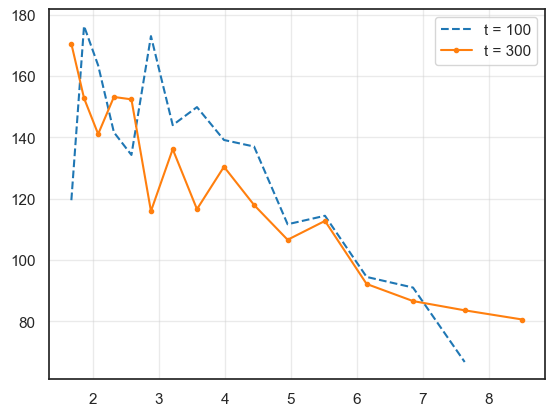

In [ ]:
plt.plot(cent, sig_bin[0], ls = "dashed", label = f"t = {t[0]}")
plt.plot(cent, sig_bin[-1], marker = "o",ms = 3,label = f"t = {t[-1]}")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

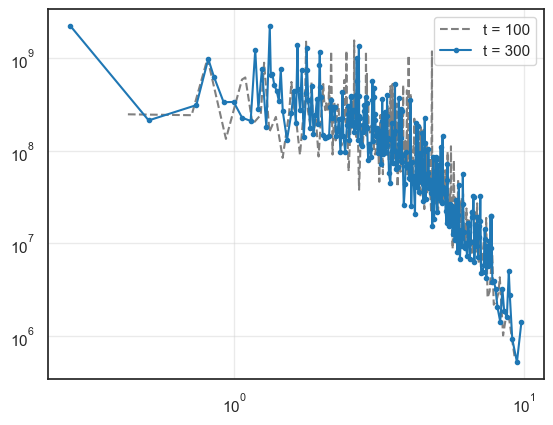

In [ ]:
plt.loglog(bins[0], rho[0], c="grey", ls = "dashed", label = f"t = {t[0]}")
plt.loglog(bins[-1], rho[-1], marker = "o",ms = 3,label = f"t = {t[-1]}")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

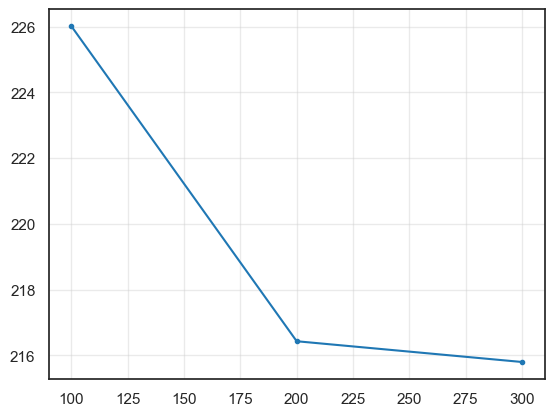

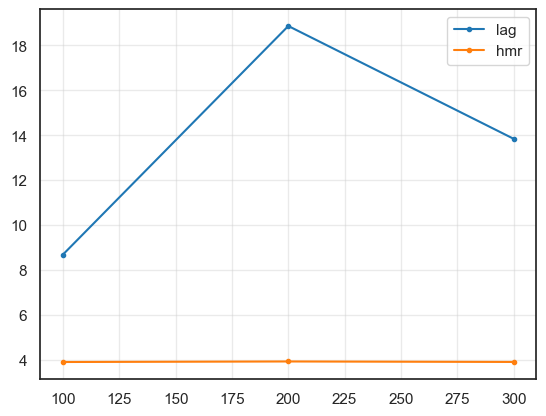

In [ ]:
plt.plot(t, sigma, marker = "o",ms = 3)
plt.grid(True, alpha=0.4)
plt.show()
plt.plot(t, lag, marker = "o",ms = 3,label="lag")
plt.plot(t, hmr, marker = "o",ms = 3,label="hmr")
plt.legend()
plt.grid(True, alpha=0.4)

In [ ]:
def get_vc(r_pc, M_host):
    g = g_mond(r_pc, M_host, R_kpc = 100, M_host = 0)  
    return np.sqrt(g * r_pc) 

def get_vs(e, r_pc, M_host):
    vx = e * get_vc(r_pc, M_host)
    vy = get_vc(r_pc, M_host) * np.sqrt(1 - e**2)
    return vx, vy

print(v_inf(8.4e10))
get_vs(e = 0.9, r_pc = 200000, M_host = 8.4e10)

191.26333095112358


(np.float64(174.2755024230617), np.float64(84.40547815521151))

In [7]:
ph = [0,0,0]
vh = [0,0,0]
ps = [400,0,0]
vs = [0,100,0]
merge_gal_shift("/Users/olgahinke/Desktop/Uni/THESIS/codes/mw_3_0.5.txt", "/Users/olgahinke/Desktop/Uni/THESIS/codes/sersic_0.3_efe.txt",ph, vh, ps, vs)

Written 51000 particles to /Users/olgahinke/Desktop/Uni/THESIS/codes/host_with_dwarf.txt
